In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhmores/spotify-top-100-songs-of-20152019")

print("Path to dataset files:", path)


c:\Users\louis\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\louis\.cache\kagglehub\datasets\muhmores\spotify-top-100-songs-of-20152019\versions\4


In [2]:
file = os.listdir(path)

In [3]:
csv_file_path = os.path.join(path, 'Spotify 2010 - 2019 Top 100.csv')
df = pd.read_csv(csv_file_path)
df.head(3)

,title,artist,top genre,year released,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,top year,artist type
0,STARSTRUKK (feat. Katy Perry),3OH!3,dance pop,2009.0,2022‑02‑17,140.0,81.0,61.0,-6.0,23.0,23.0,203.0,0.0,6.0,70.0,2010.0,Duo
1,My First Kiss (feat. Ke$ha),3OH!3,dance pop,2010.0,2022‑02‑17,138.0,89.0,68.0,-4.0,36.0,83.0,192.0,1.0,8.0,68.0,2010.0,Duo
2,I Need A Dollar,Aloe Blacc,pop soul,2010.0,2022‑02‑17,95.0,48.0,84.0,-7.0,9.0,96.0,243.0,20.0,3.0,72.0,2010.0,Solo


In [4]:
df.shape

(1003, 17)

In [5]:
df.isna().sum()

title            3
artist           3
top genre        3
year released    3
added            3
bpm              3
nrgy             3
dnce             3
dB               3
live             3
val              3
dur              3
acous            3
spch             3
pop              3
top year         3
artist type      3
dtype: int64

In [6]:
df[df["title"].isna()]

,title,artist,top genre,year released,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,top year,artist type
1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df = df.dropna()

In [8]:
numeric_values = df.select_dtypes(include=['number'])

array([[<Axes: title={'center': 'year released'}>,
        <Axes: title={'center': 'bpm'}>,
        <Axes: title={'center': 'nrgy'}>],
       [<Axes: title={'center': 'dnce'}>, <Axes: title={'center': 'dB'}>,
        <Axes: title={'center': 'live'}>],
       [<Axes: title={'center': 'val'}>, <Axes: title={'center': 'dur'}>,
        <Axes: title={'center': 'acous'}>],
       [<Axes: title={'center': 'spch'}>,
        <Axes: title={'center': 'pop'}>,
        <Axes: title={'center': 'top year'}>]], dtype=object)

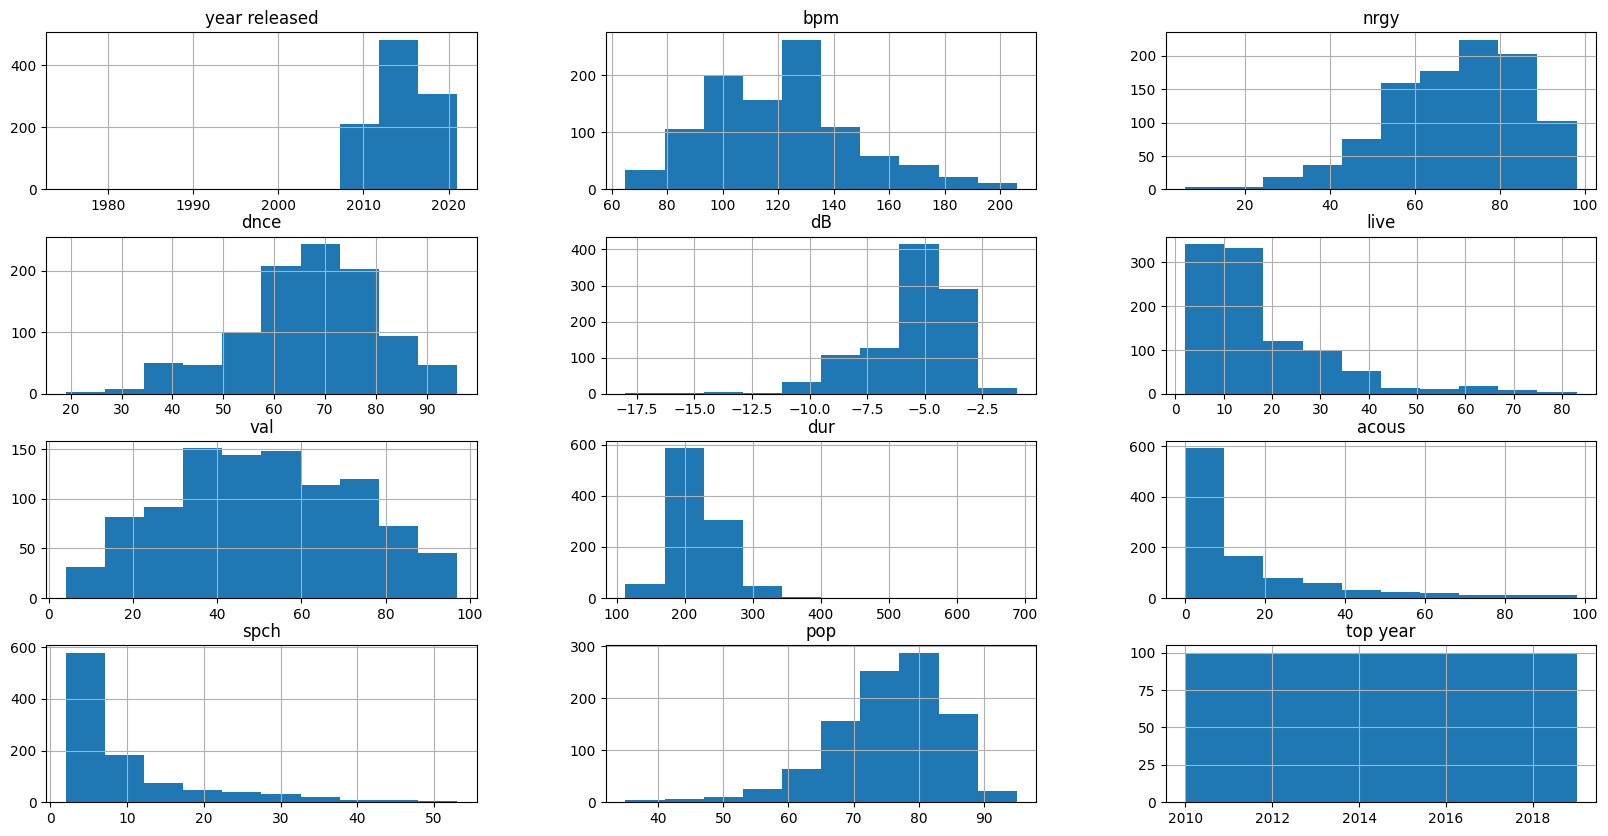

In [9]:
df.hist(figsize=(20,10))

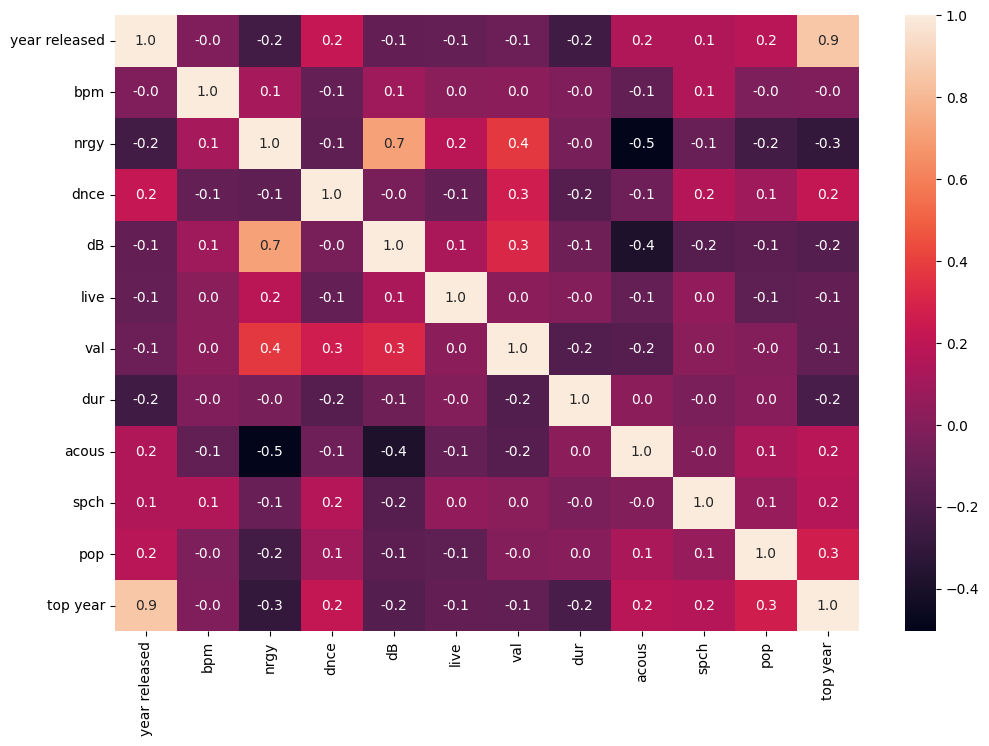

In [10]:
fig, axs = plt.subplots(nrows=1, ncols = 1, figsize = (12,8))
sns.heatmap(numeric_values.corr(), annot=True, fmt=".1f")
plt.show()

In [11]:
grouped_genre = df.groupby("top genre")["pop"].mean().sort_values(ascending=False).reset_index()
grouped_genre

,top genre,pop
0,chill pop,94.0
1,dark clubbing,89.0
2,australian psych,88.0
3,bedroom pop,88.0
4,dfw rap,84.3
...,...,...
127,dancefloor dnb,49.0
128,lilith,46.0
129,electro house,45.0
130,deep disco house,44.0


In [12]:
fig = px.bar(grouped_genre,x="top genre",y="pop")
fig.show()

In [13]:
df

,title,artist,top genre,year released,added,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop,top year,artist type
0,STARSTRUKK (feat. Katy Perry),3OH!3,dance pop,2009.0,2022‑02‑17,140.0,81.0,61.0,-6.0,23.0,23.0,203.0,0.0,6.0,70.0,2010.0,Duo
1,My First Kiss (feat. Ke$ha),3OH!3,dance pop,2010.0,2022‑02‑17,138.0,89.0,68.0,-4.0,36.0,83.0,192.0,1.0,8.0,68.0,2010.0,Duo
2,I Need A Dollar,Aloe Blacc,pop soul,2010.0,2022‑02‑17,95.0,48.0,84.0,-7.0,9.0,96.0,243.0,20.0,3.0,72.0,2010.0,Solo
3,Airplanes (feat. Hayley Williams of Paramore),B.o.B,atl hip hop,2010.0,2022‑02‑17,93.0,87.0,66.0,-4.0,4.0,38.0,180.0,11.0,12.0,80.0,2010.0,Solo
4,Nothin' on You (feat. Bruno Mars),B.o.B,atl hip hop,2010.0,2022‑02‑17,104.0,85.0,69.0,-6.0,9.0,74.0,268.0,39.0,5.0,79.0,2010.0,Solo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,SICKO MODE,Travis Scott,hip hop,2018.0,2020‑06‑22,155.0,73.0,83.0,-4.0,12.0,45.0,313.0,1.0,22.0,86.0,2019.0,Solo
996,EARFQUAKE,"Tyler, The Creator",hip hop,2019.0,2020‑06‑22,80.0,50.0,55.0,-9.0,80.0,41.0,190.0,23.0,7.0,85.0,2019.0,Solo
997,Boasty (feat. Idris Elba),Wiley,grime,2019.0,2020‑06‑22,103.0,77.0,89.0,-5.0,9.0,46.0,177.0,1.0,7.0,68.0,2019.0,Solo
998,Strike a Pose (feat. Aitch),Young T & Bugsey,afroswing,2019.0,2020‑08‑20,138.0,58.0,53.0,-6.0,10.0,59.0,214.0,1.0,10.0,67.0,2019.0,Duo


In [14]:
def assign_category(genre):
    if 'pop' in genre.lower(): 
        return 'Pop'
    elif 'rock' in genre.lower(): 
        return 'Rock'
    else:
        return genre

In [15]:
df['Genre category'] = df['top genre'].apply(assign_category)

In [33]:
top_genres = df["top genre"].value_counts()
top_genres = top_genres[top_genres > 10].index

df_filtered = df[df["top genre"].isin(top_genres)]



In [48]:
fig = px.violin(
    df_filtered,
    x="top genre",
    y="pop",
    box = True
    )

fig.update_layout(width=1200, height=600)

fig.show()

In [51]:
import sklearn
from sklearn.linear_model import LinearRegression

In [105]:
df.isna().sum()

title             0
artist            0
top genre         0
year released     0
added             0
bpm               0
nrgy              0
dnce              0
dB                0
live              0
val               0
dur               0
acous             0
spch              0
pop               0
top year          0
artist type       0
Genre category    0
dtype: int64

Train-Test-Split

In [96]:
X = df.drop(columns=["pop","title","artist"])
y = df["pop"]

In [104]:
X.columns

Index(['top genre', 'year released', 'added', 'bpm', 'nrgy', 'dnce', 'dB',
       'live', 'val', 'dur', 'acous', 'spch', 'top year', 'artist type',
       'Genre category'],
      dtype='object')

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 101)

Separating numerical & non numerical values

In [ ]:
numerical_values = X_train.select_dtypes(include="number").columns.to_list()
non_numerical_values = X_train.select_dtypes(exclude="number").columns.to_list()

In [ ]:
non_numerical_values

['top genre', 'added', 'artist type', 'Genre category']

Pre-processing

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

In [106]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_values),  
        ('cat', OneHotEncoder(handle_unknown='ignore'), non_numerical_values)  
    ])

In [107]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year released', 'bpm',
                                                   'nrgy', 'dnce', 'dB', 'live',
                                                   'val', 'dur', 'acous',
                                                   'spch', 'top year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['top genre', 'added',
                                                   'artist type',
                                                   'Genre category'])])),
                ('classifier', LinearRegression())])

In [108]:
pipeline.score(X_test, y_test)

0.18355118506058887

In [111]:
from sklearn.ensemble import RandomForestRegressor

In [112]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestRegressor())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year released', 'bpm',
                                                   'nrgy', 'dnce', 'dB', 'live',
                                                   'val', 'dur', 'acous',
                                                   'spch', 'top year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['top genre', 'added',
                                                   'artist type',
                                                   'Genre category'])])),
                ('classifier', RandomForestRegressor())])

In [113]:
pipeline.score(X_test, y_test)

0.11339544478181585

In [115]:
X = df.drop(columns=["pop","title","artist",'year released','top year'])
y = df["pop"]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 101)
numerical_values = X_train.select_dtypes(include="number").columns.to_list()
non_numerical_values = X_train.select_dtypes(exclude="number").columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_values),  
        ('cat', OneHotEncoder(handle_unknown='ignore'), non_numerical_values)  
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearRegression())
])

pipeline.fit(X_train, y_train)

pipeline.score(X_test, y_test)

0.11337081501027468